# VIMA demo (spatial transcriptomics - MERFISH)

In [11]:
import numpy as np
import glob, os
import pandas as pd
import vima
import torch
np.random.seed(0)
torch.set_default_device('mps') # edit as appropriate to hardware

In this demo, we will illustrate how to preprocess and then analyze a case-control spatial transcriptomics dataset using VIMA. For non-transcript-based modalities, see the immunofluorescence demo.

## Input

We assume in this demo that:
1) Genes and transcripts have already undergone basic QC (e.g., low-quality genes removed, low-quality transcripts removed). This is the type of QC that would ordinary be done prior to many downstream tasks such as cell segmentation.
1) Slides with multiple samples on them have already been split up into separate files.

## Overview of this notebook

The `vima` workflow has three major parts: 1) preprocessing, whereby the marker levels (or expression counts) in the pixels are normalized, non-spatial batch effects and sample-specific artifacts are removed, and the markers are converted into meta-markers, 2) model training, and 3) case-control analysis

## 1. Preprocessing

Here we specify what is needed for our preprocessing pipeline to work, including: the number of meta-markers to produce, the name of the folder in which we will store the output, and information about the markers that are profiled in the raw data

In [2]:
# raw data loader
def load(path):
    sid = os.path.basename(path).replace('.csv', '')
    data = pd.read_csv(path, dtype={9: str}) # make sure the 9th column (gene ID) which is -1 for blank probes, is read as a str
    return sid, data

resolution = 10 #microns per pixel
nmetamarkers = 10 # desired number of meta-markers
filepaths = glob.glob(f'data/ST/raw/*.csv')
outdir = f'data/ST/{resolution}u'

In [ ]:

vima.pp.st.prepare_merfish(load=load,
                           filepaths=filepaths,
                           x_col='global_x',
                           y_col='global_y',
                           gene_col='gene',
                           outdir=outdir,
                           pixel_size=resolution)
# to-do: include a note about how with xenium5k data we recommend HVG selection and prepare_xenium5k is good for that

Creating metapixels prior to PCA
	(will randomly downsample to 200000 metapixels per sample if needed.)


100%|███████████████████████████████████████████████████████████████| 10/10 [00:40<00:00,  4.04s/it]


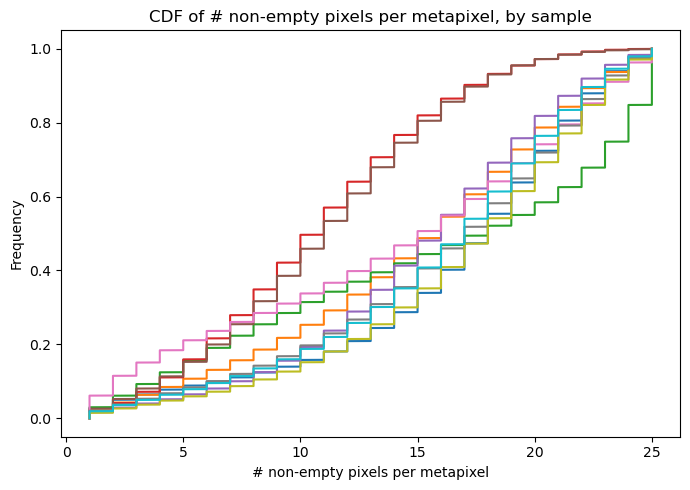

merging and standardizing metapixels
Metapixel matrix: 2,000,000 pixels × 170 features
performing PCA...

top/bottom features per PC (features with negative loadings preceded by "-"):
     PC1     PC2     PC3      PC4      PC5     PC6     PC7      PC8      PC9     PC10
 SECRET5     MOG SLC24A2   CLSTN2     EBF1   CBLN2    DGKG     CD74     GAD2      TNR
SECRET20    CD22   PEX5L    NTNG2      DCN   LAMP5  SORCS3     CTSS  SLC32A1    LUZP2
 SECRET7   UNC5B  CLSTN2    FEZF2    PALMD    CUX2    RYR3    LRRK1  ZNF385D TMEM255A
SECRET18   PDE4B  NKAIN2   HS3ST2  NOSTRIN  HS6ST3   GRIK3   RBFOX3 KIAA1217    ITGA8
 SECRET8   FBXL7  HS3ST2    SNTB1     CDH6 ADAMTS3   ASIC2    TACR1     LHX6    PDE4B
 -NKAIN2 -GRIN2A   -RYR3    -CUX2   -NPAS3  -ASTN2   -EBF1   -ROBO1     -TOX    -RYR3
  -UNC5B   -HCN1   -GPC5    -GAD2    -NFIA   -ANK1 -ATRNL1 -SLC24A2    -RORB   -TACR1
    -MOG -ATRNL1   -PAX6    -DLX1 -SLC14A1 -GRIN3A -KCNIP4   -PEX5L     -DCC   -UNC5B
   -KAZN -RBFOX1   -EGFR -SLC32A1  -ETNPPL

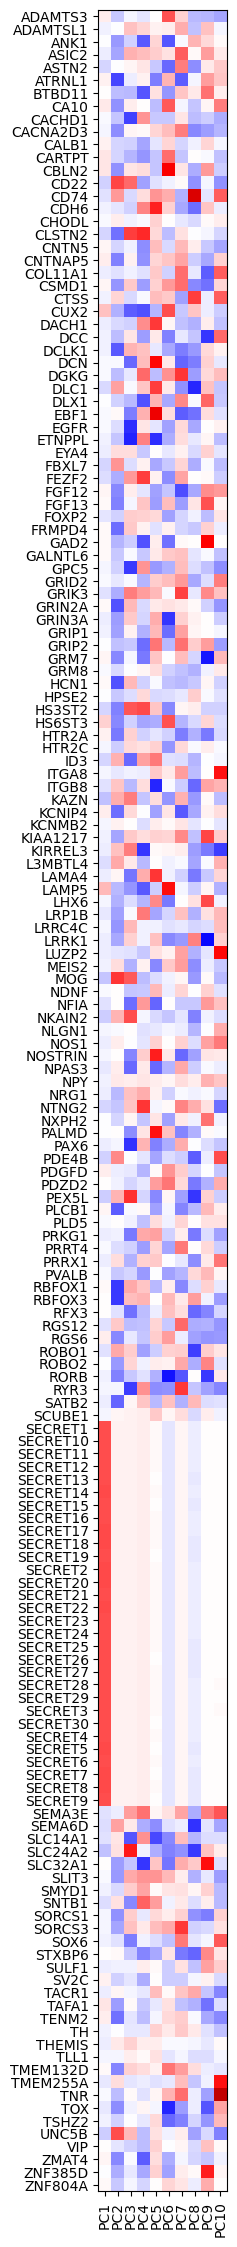

Applying PCA projection to each sample


100%|███████████████████████████████████████████████████████████████| 10/10 [00:14<00:00,  1.42s/it]


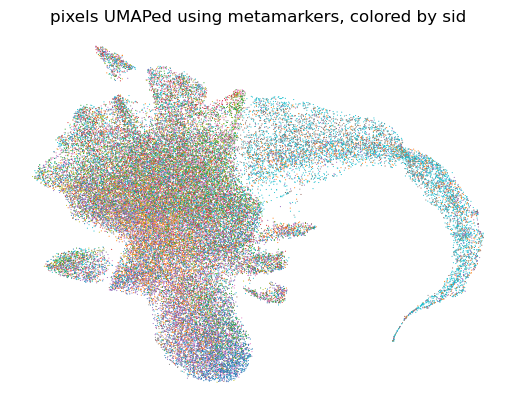

Avg LISI (sid): 4.16  [8.78 = perfect mixing, 1 = not mixed]

Running Harmony...


2026-04-29 14:02:40,894 - harmonypy - INFO - Running Harmony
2026-04-29 14:02:40,894 - harmonypy - INFO -   Parameters:
2026-04-29 14:02:40,895 - harmonypy - INFO -     max_iter_harmony: 10
2026-04-29 14:02:40,895 - harmonypy - INFO -     max_iter_kmeans: 4
2026-04-29 14:02:40,895 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-04-29 14:02:40,896 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-04-29 14:02:40,896 - harmonypy - INFO -     nclust: 100
2026-04-29 14:02:40,896 - harmonypy - INFO -     block_size: 0.05
2026-04-29 14:02:40,897 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-04-29 14:02:40,897 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-04-29 14:02:40,898 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-04-29 14:02:40,898 - harmonypy - INFO -     verbose: True
2026-04-29 14:02:40,898 - harmonypy - INFO -     random_state: 0
2026-04-29 14:02:40,898 - harmonypy - INFO -   Data: 10 PCs × 2098214 cells
2026-04-29 14:02:40,899 

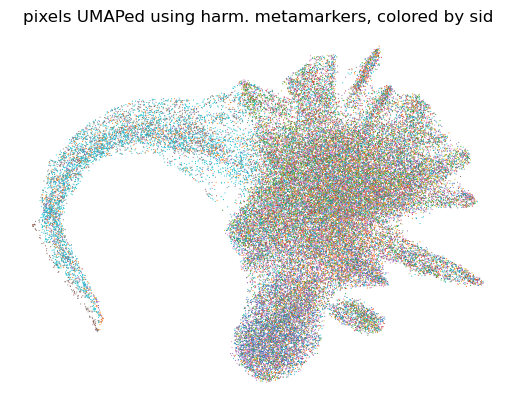

Avg LISI (sid): 4.75  [8.78 = perfect mixing, 1 = not mixed]



100%|███████████████████████████████████████████████████████████████| 10/10 [00:06<00:00,  1.46it/s]


In [3]:
# perform qc and convert markers to meta-markers
repname = f'{nmetamarkers}metamarkers'
allpixels_pca = vima.pp.pca_pixels(outdir, repname, nmetamarkers=nmetamarkers)

# harmonize the meta-markers and write the results
harmpixels = vima.pp.harmonize(allpixels_pca)
vima.pp.write_harmonized(outdir, repname, harmpixels)

Finally, `vima` offers some sanity checks to give us a chance to spot any obvious problems

all PCs of one sample


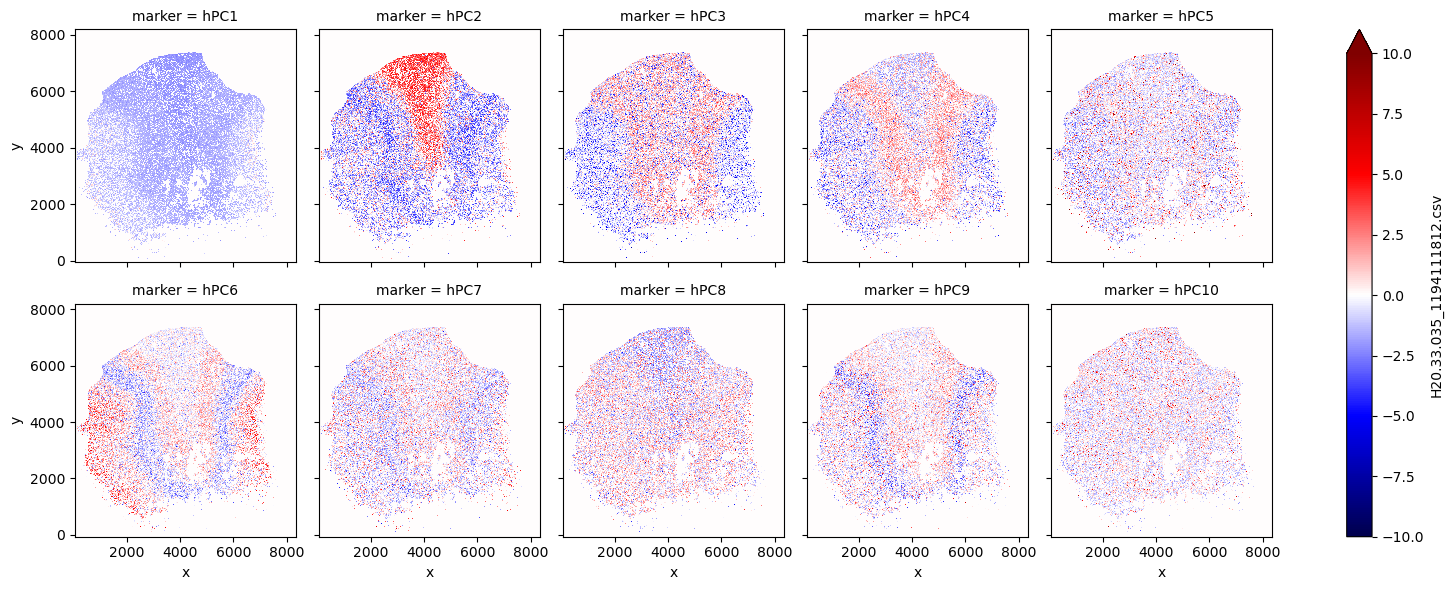

histogram of each pc


100%|███████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  5.09it/s]


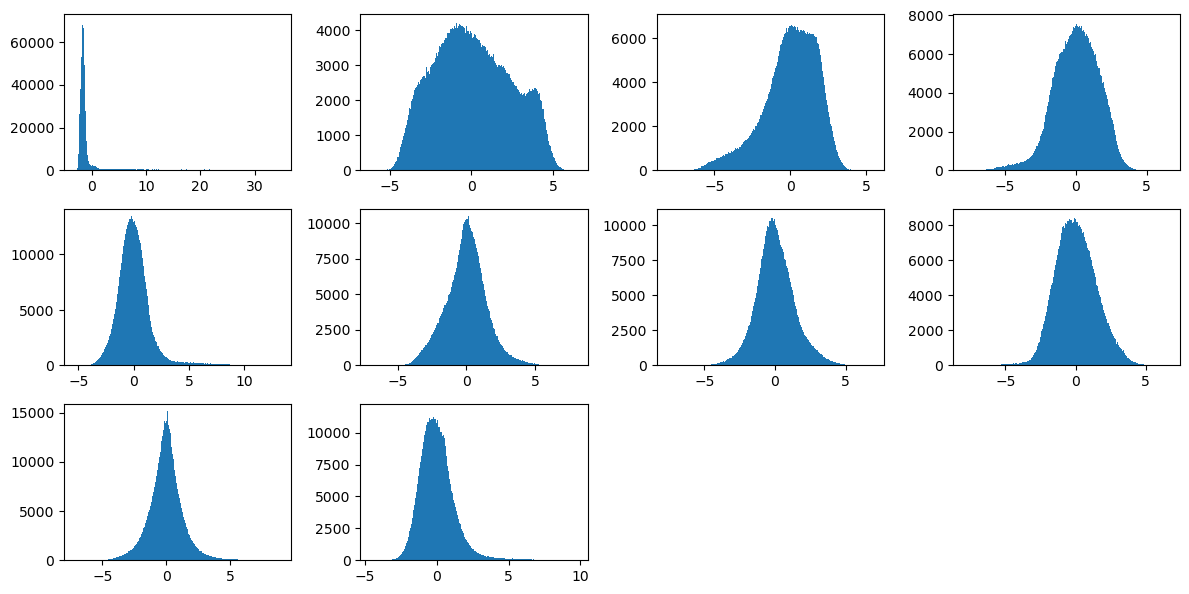

PC1 of several samples


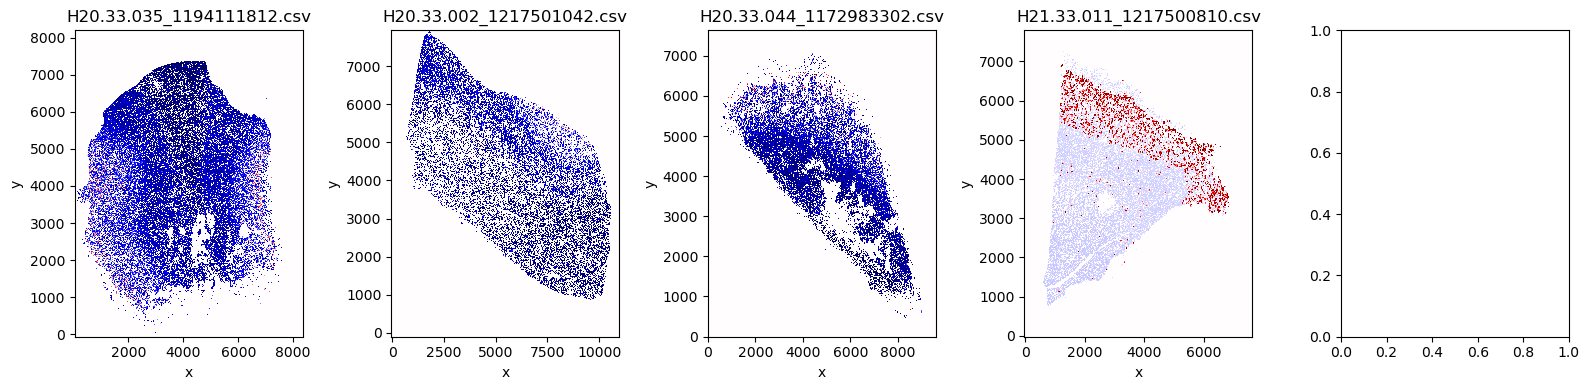

In [4]:
# visual sanity checks
vima.pp.sanity_checks(outdir, repname)

## 2. Model training

We now turn to training the `vima` model on our preprocessed data. This involves reading in the data, generating tissue patches, and training the variational autoencoder.

We first read in all the samples together with their metadata

In [12]:
# read in samples
samples = vima.read_samples(f'data/ST/10u/10metamarkers/*.nc')

# read in sample metadata
samplemeta = pd.read_csv('data/ST/samplemeta.tsv',
                         sep='\t').set_index('sid', drop=True)

100%|███████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  6.81it/s]


We now generate two sets of patches: one for training, and a smaller set of "high-quality" patches for the case-control analysis

In [13]:
# choose which patches to train on
P = vima.PatchCollection(samples)
P

100%|███████████████████████████████████████████████████████████████| 10/10 [00:04<00:00,  2.31it/s]


[PatchCollection: in pytorch mode]
[PatchCollection: data augmentation is off]


PatchCollection object with npatches × width × height × nmarkers = 36076×40×40×10
	covariates: sid (10 values)

In [14]:
# choose which patches to do case/ctrl analysis on
Pdense = P.refined(max_frac_empty=0.5)
Pdense

PatchCollection object with npatches × width × height × nmarkers = 22117×40×40×10
	covariates: sid (10 values)

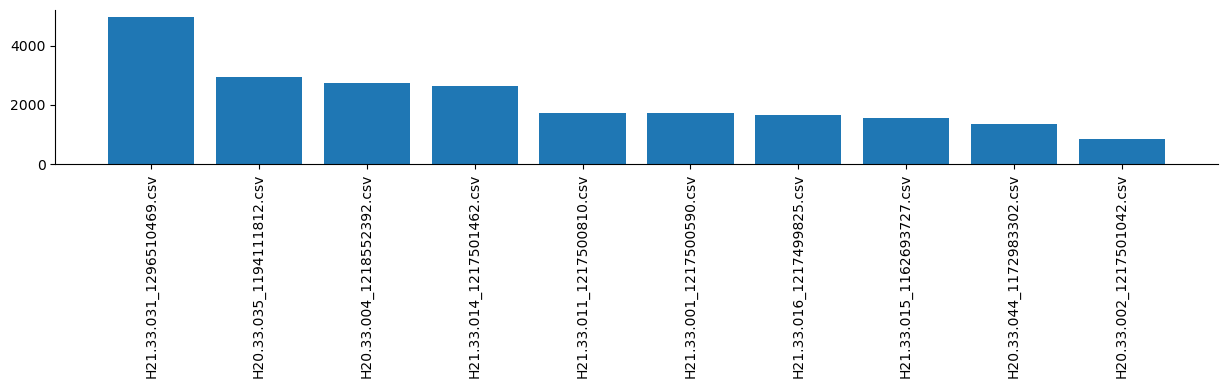

10it [00:01,  5.59it/s]
/Users/yakir/Dropbox/py/vima/src/vima/data/samples.py:92: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


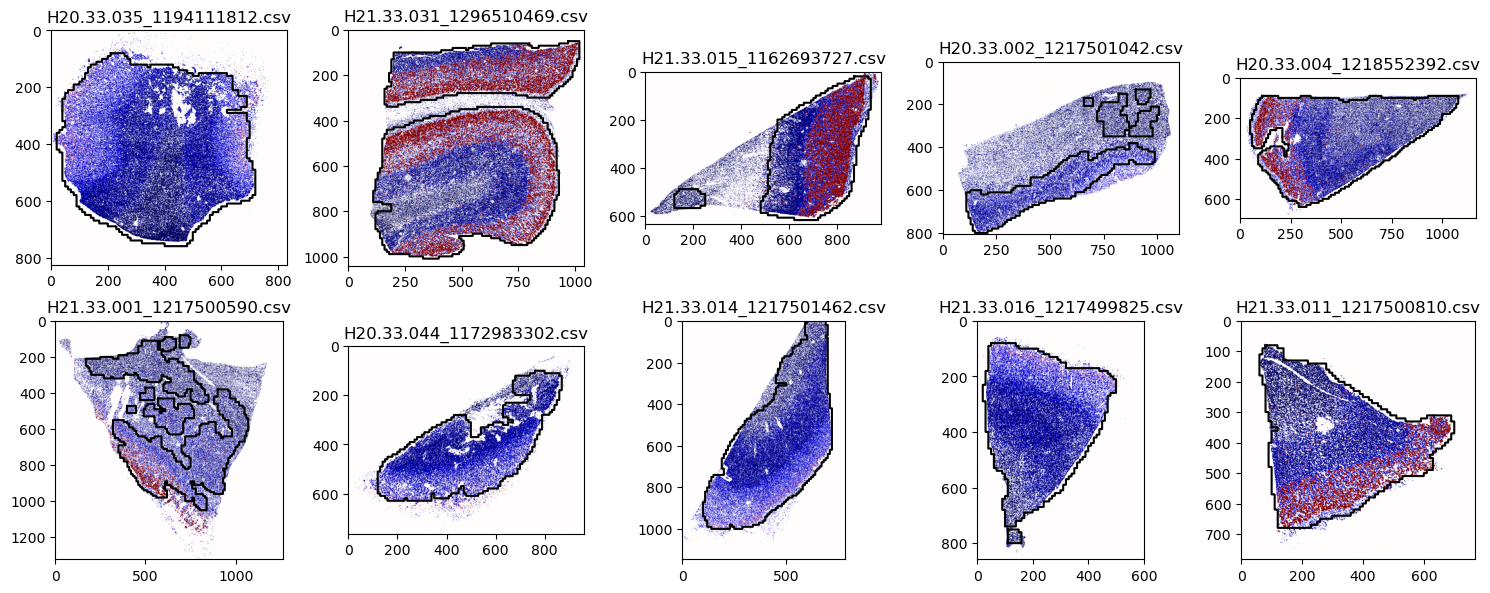

In [15]:
# visualize resulting patches
vima.d.plot_npatches_per_sample(samples, Pdense.meta)
vima.d.plot_samples_with_patches(samples.values(), 'hPC1', Pdense.meta, ncols=5, vmin=-2, vmax=2)

Now that we have the patches we can train the autoencoder and save an instance of the trained model.

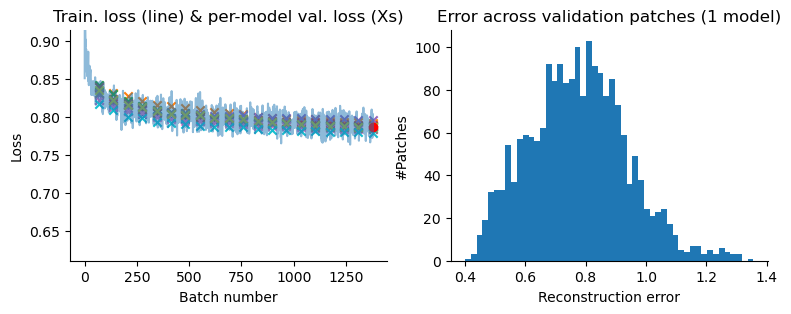

100%|███████████████████████████████████████████████████████████████| 10/10 [00:19<00:00,  1.96s/it]

End of epoch 20
Avg. val. loss: 0.7873263001441956
Time elapsed this epoch: 138.43 sec
Total time elapsed: 2764.43 sec
Best val. losses so far for each model: 0.79 0.79 0.79 0.79 0.8 0.79 0.78 0.78 0.79 0.78
Best epoch so far for each model: 20 20 20 20 20 20 20 20 20 20



In [16]:
models = vima.models.cVAE(P.nmarkers, P.covariate_sizes)
vima.fit(models, P, Pdense)
torch.save(models.state_dict(), f'data/ST/models.pt')

Once the model is trained, we load it from disk and apply it to the set of patches that are meant for case-control analysis to generate their patch fingerprints.

In [17]:
# load model
models = vima.models.cVAE(P.nmarkers, P.covariate_sizes, weights='data/ST/models.pt')
ds = vima.latentreps(models, Pdense)
ds.write_h5ad(f'data/ST/fingerprints.h5ad')

applying models
[PatchCollection: in pytorch mode]
[PatchCollection: data augmentation is off]


100%|███████████████████████████████████████████████████████████████| 23/23 [00:18<00:00,  1.27it/s]


computing nearest-neighbor graphs


100%|███████████████████████████████████████████████████████████████| 10/10 [00:19<00:00,  1.99s/it]


Now we can read in the the patch fingerprints and conduct the case-control analysis. The output is a global P-value for association as well as a set of significant microniches at FDR 10%.

## Case-control analysis

computing MAT
performing association test
P = 9.999000099990002e-05


/Users/yakir/Dropbox/py/vima/src/vima/cc.py:90: UserWarning: global association p-value attained minimal possible value. Consider increasing Nnull
  warnings.warn('global association p-value attained minimal possible value. '+\


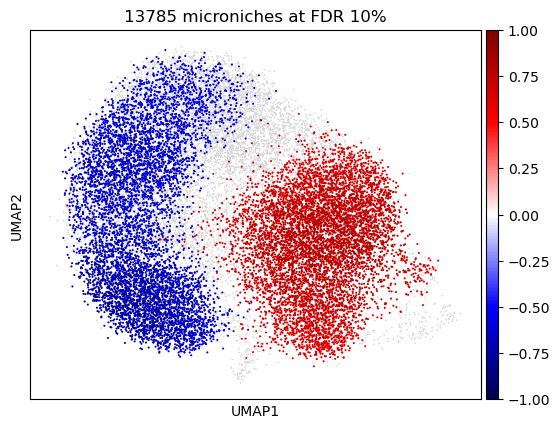

In [24]:
ds = vima.Fingerprints.read_h5ad('data/ST/fingerprints.h5ad')
p, D = vima.association(ds, samplemeta.case, 'sid', donorids=samplemeta.donor)
vima.v.plot_association(D)

In [30]:
cells = pd.read_csv('data/ST/cell_metadata.tsv', sep='\t')
cells['sid'] = cells.Section.str.split('_').str[0:2].str.join('_')

D.obs['donor'] = D.obs.sid.map(samplemeta.donor)
D.obsm['abundances'] = vima.cell_type_counts(cells, D.obs,
    'sid', 'subclass_name', 'x', 'y')
D.obsm['expr'] = vima.expression_profiles('data/ST/10u/normalized', D.obs)

100%|███████████████████████████████████████████████████████████████| 10/10 [00:12<00:00,  1.25s/it]


In [67]:
from importlib import reload
reload(vima.patchfeatures)
D.obs['sig_pos'] = (D.obs.mncoef > 0) & (D.obs.mncoef_fdr <= 0.05)
enrichments = vima.patchfeatures.test_features(D.obsm['abundances'],
              D.obs.sig_pos, perm_key=D.obs.donor)
enrichments[enrichments.pvals_adj <= 0.1].sort_values(by='log2fc', ascending=False)

Comparing 5579 patches (Group A) to 16538 patches (Group B).


,median_a,median_b,mean_a,mean_b,log2fc,log2fc_means,pvals,pvals_adj
L2/3 IT,0.280488,0.010929,0.229833,0.097143,4.681710,1.242397,0.02368,0.053818
L5/6 NP,0.000000,0.000000,0.000534,0.013284,0.000000,-4.636087,0.00200,0.008333
Sncg,0.000000,0.000000,0.004878,0.002740,0.000000,0.832038,0.00588,0.015025
Pax6,0.000000,0.000000,0.003478,0.002315,0.000000,0.587251,0.00601,0.015025
L6 CT,0.000000,0.000000,0.004322,0.015084,0.000000,-1.803230,0.03369,0.070187
Sst,0.010929,0.025521,0.015510,0.027514,-1.223532,-0.826973,0.00585,0.015025
L5 ET,0.000000,0.005236,0.000815,0.011152,-22.319924,-3.774933,0.00200,0.008333
L6b,0.000000,0.006849,0.007819,0.028354,-22.707529,-1.858449,0.00406,0.014500
L6 IT Car3,0.000000,0.008230,0.003890,0.027810,-22.972541,-2.837605,0.00200,0.008333
L6 IT,0.000000,0.012821,0.005026,0.054478,-23.611951,-3.438280,0.00200,0.008333


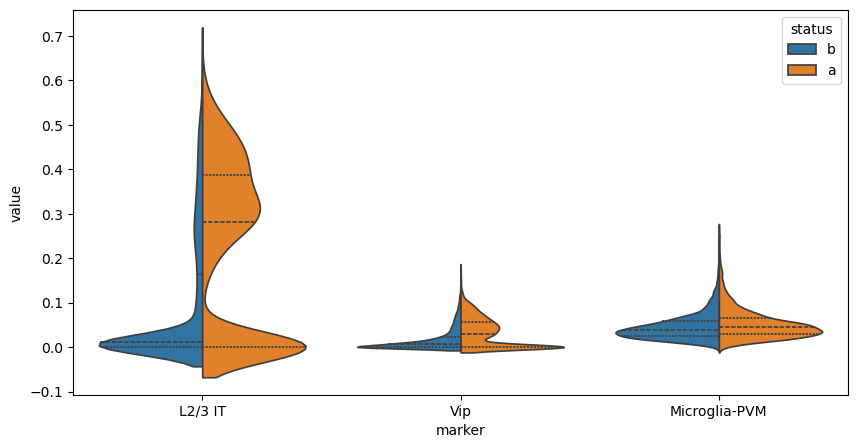

In [70]:
reload(vima.vis)
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
vima.vis.plot_features(D.obsm['abundances'], D.obs.sig_pos, n_top=3)

Comparing 5579 patches (Group A) to 16538 patches (Group B).


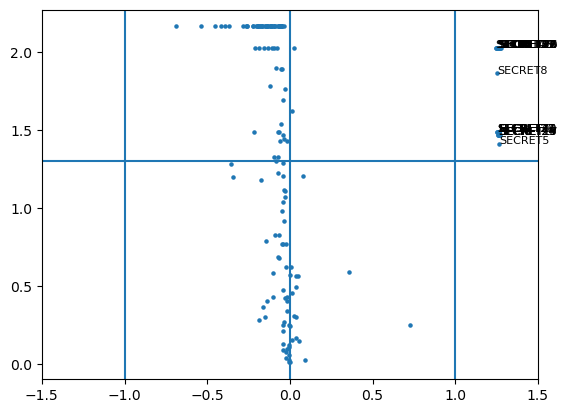

In [85]:
ge_enrichments = vima.patchfeatures.test_features(D.obsm['expr'],
              D.obs.sig_pos, perm_key=D.obs.donor)
ge_enrichments[ge_enrichments.pvals_adj <= 0.05].sort_values(by='diff', ascending=False)
plt.scatter(ge_enrichments['diff'], -np.log10(ge_enrichments.pvals_adj), s=5)
for idx, row in ge_enrichments[ge_enrichments['diff'] > 1].iterrows():
    plt.text(row['diff'], -np.log10(row['pvals_adj']), idx, fontsize=8)
plt.axhline(-np.log10(0.05)); plt.axvline(x=0)
plt.axvline(1); plt.axvline(-1)
plt.xlim(-1.5, 1.5)
plt.show()